In [1]:
import sys
import os

# Add 'src' to python path so we can import our modules directly
sys.path.append("../src")

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from data_loader import load_dms_assay
from structure_engine import (
    predict_esmfold, 
    fetch_alphafold_db, 
    extract_plddt, 
    calculate_ca_rmsd
)

print("Environment and local modules linked successfully!")

Environment and local modules linked successfully!


In [2]:
TARGET_ASSAY = "BRCA1_HUMAN"

# Fetch 5 sequences from your local CSV using your existing loader
sequence_batch = load_dms_assay(TARGET_ASSAY, max_mutants=5)

for variant_id, seq in sequence_batch.items():
    print(f"Target: {variant_id} | Sequence Length: {len(seq)} aa")

Loading data from: ../data/raw/DMS_ProteinGym_substitutions\BRCA1_HUMAN_Findlay_2018.csv
Successfully loaded 5 sequences for assay: BRCA1_HUMAN
Target: BRCA1_HUMAN_M1I | Sequence Length: 1863 aa
Target: BRCA1_HUMAN_M1V | Sequence Length: 1863 aa
Target: BRCA1_HUMAN_M1T | Sequence Length: 1863 aa
Target: BRCA1_HUMAN_M1R | Sequence Length: 1863 aa
Target: BRCA1_HUMAN_M1L | Sequence Length: 1863 aa


In [3]:
plddt_results = {}
pdb_paths = {}

# 1. Fetch AlphaFold Ground Truth for BRCA1 (UniProt: P38398)
af_pdb = fetch_alphafold_db("P38398")
if af_pdb:
    pdb_paths["AlphaFold_WT"] = af_pdb
    plddt_results["AlphaFold_WT"] = extract_plddt(af_pdb)

# 2. Predict Structures for Mutants using ESMFold
for variant_id, seq in sequence_batch.items():
    pdb_path = predict_esmfold(variant_id, seq)
    if pdb_path:
        pdb_paths[variant_id] = pdb_path
        plddt_results[variant_id] = extract_plddt(pdb_path)

print(f"\nCaptured {len(pdb_paths)} structural models.")

[CACHE] Found existing AlphaFold structure: ../data/processed/predicted_structures/alphafold\AF_P38398.pdb
[CACHE] Found existing ESMFold structure: ../data/processed/predicted_structures/esmfold\BRCA1_HUMAN_M1I_esmfold.pdb
[CACHE] Found existing ESMFold structure: ../data/processed/predicted_structures/esmfold\BRCA1_HUMAN_M1V_esmfold.pdb
[CACHE] Found existing ESMFold structure: ../data/processed/predicted_structures/esmfold\BRCA1_HUMAN_M1T_esmfold.pdb
[CACHE] Found existing ESMFold structure: ../data/processed/predicted_structures/esmfold\BRCA1_HUMAN_M1R_esmfold.pdb
[CACHE] Found existing ESMFold structure: ../data/processed/predicted_structures/esmfold\BRCA1_HUMAN_M1L_esmfold.pdb

Captured 6 structural models.


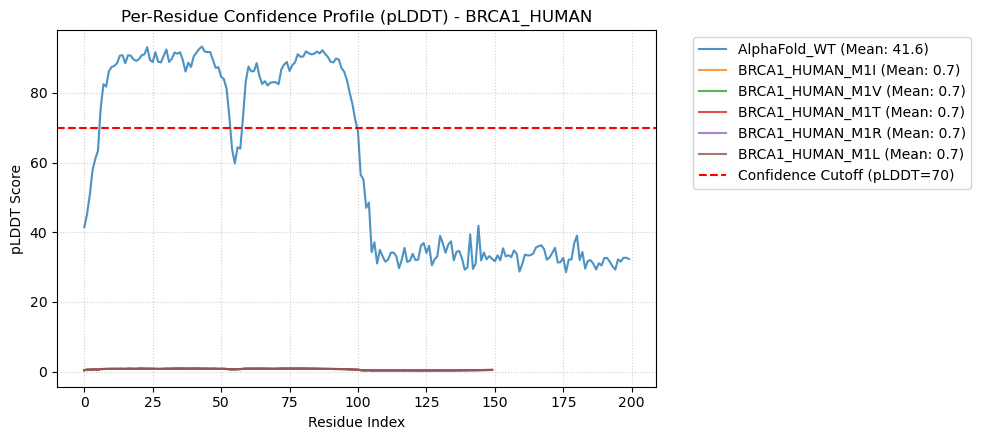

In [4]:
plt.figure(figsize=(10, 4.5))

for model_name, scores in plddt_results.items():
    plt.plot(scores[:200], label=f"{model_name} (Mean: {np.mean(scores):.1f})", alpha=0.8)

plt.axhline(70, color="red", linestyle="--", label="Confidence Cutoff (pLDDT=70)")
plt.title(f"Per-Residue Confidence Profile (pLDDT) - {TARGET_ASSAY}")
plt.xlabel("Residue Index")
plt.ylabel("pLDDT Score")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

In [5]:
# Compare structural deviation (RMSD) between the first ESMFold mutant and AlphaFold WT
keys = list(pdb_paths.keys())

if len(keys) >= 2:
    struct_a = keys[0]
    struct_b = keys[1]
    
    rmsd_val = calculate_ca_rmsd(pdb_paths[struct_a], pdb_paths[struct_b])
    
    print("--- Structural Validation Summary ---")
    print(f"Structure A: {struct_a}")
    print(f"Structure B: {struct_b}")
    print(f"C-alpha RMSD: {rmsd_val:.3f} Å")
    
    if rmsd_val < 2.0:
        print("Assessment: High structural similarity (Conformationally stable).")
    else:
        print("Assessment: Significant structural deviation detected.")

--- Structural Validation Summary ---
Structure A: AlphaFold_WT
Structure B: BRCA1_HUMAN_M1I
C-alpha RMSD: 14.802 Å
Assessment: Significant structural deviation detected.


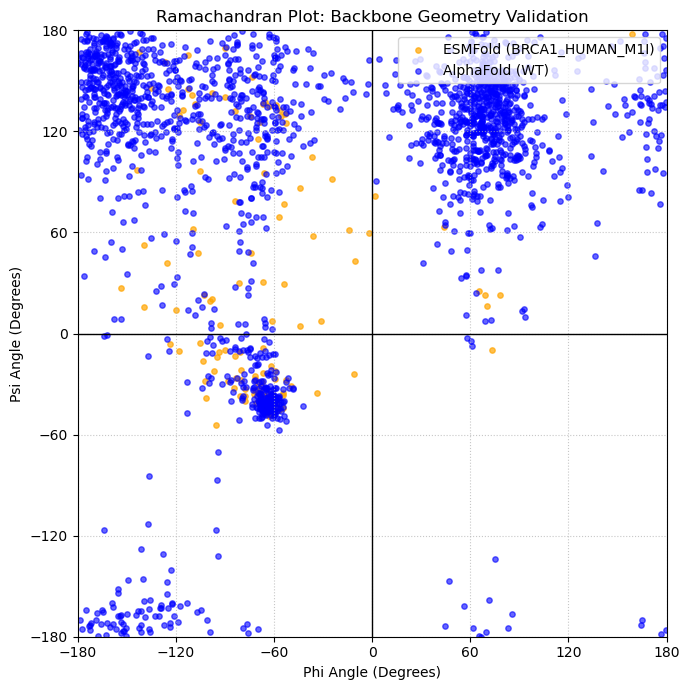

In [6]:
# Cell 6: Ramachandran Plot (Structural Geometry Validation)
import math
from Bio.PDB import PDBParser, PPBuilder
import matplotlib.pyplot as plt

def get_phi_psi_angles(pdb_path):
    """Extracts backbone Phi and Psi angles (in degrees) from a PDB file."""
    parser = PDBParser(QUIET=True)
    structure = parser.get_structure("protein", pdb_path)
    ppb = PPBuilder()
    
    angles = []
    # Iterate through all polypeptides in the structure
    for pp in ppb.build_peptides(structure):
        for phi_psi in pp.get_phi_psi_list():
            # Ensure both angles exist (N-term and C-term residues miss one)
            if phi_psi[0] is not None and phi_psi[1] is not None:
                phi = math.degrees(phi_psi[0])
                psi = math.degrees(phi_psi[1])
                angles.append((phi, psi))
    return angles

# 1. Calculate angles for AlphaFold WT and your first ESMFold mutant
af_angles = get_phi_psi_angles(pdb_paths["AlphaFold_WT"])
struct_b_name = [k for k in pdb_paths.keys() if k != "AlphaFold_WT"][0]
esm_angles = get_phi_psi_angles(pdb_paths[struct_b_name])

# 2. Generate the Ramachandran Plot
plt.figure(figsize=(7, 7))

# Plot ESMFold (Prediction)
plt.scatter([x[0] for x in esm_angles], [x[1] for x in esm_angles], 
            s=15, alpha=0.7, color='orange', label=f"ESMFold ({struct_b_name})")

# Plot AlphaFold (Ground Truth)
plt.scatter([x[0] for x in af_angles], [x[1] for x in af_angles], 
            s=15, alpha=0.6, color='blue', label="AlphaFold (WT)")

# Formatting the plot geometry
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)
plt.xlim(-180, 180)
plt.ylim(-180, 180)
plt.xticks(range(-180, 181, 60))
plt.yticks(range(-180, 181, 60))
plt.xlabel("Phi Angle (Degrees)")
plt.ylabel("Psi Angle (Degrees)")
plt.title("Ramachandran Plot: Backbone Geometry Validation")
plt.legend(loc="upper right")
plt.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()